Image Approximation with Fourier and Wavelets
=============================================

*Important:* Please read the [installation page](http://gpeyre.github.io/numerical-tours/installation_python/) for details about how to install the toolboxes.
$\newcommand{\dotp}[2]{\langle #1, #2 \rangle}$
$\newcommand{\enscond}[2]{\lbrace #1, #2 \rbrace}$
$\newcommand{\pd}[2]{ \frac{ \partial #1}{\partial #2} }$
$\newcommand{\umin}[1]{\underset{#1}{\min}\;}$
$\newcommand{\umax}[1]{\underset{#1}{\max}\;}$
$\newcommand{\umin}[1]{\underset{#1}{\min}\;}$
$\newcommand{\uargmin}[1]{\underset{#1}{argmin}\;}$
$\newcommand{\norm}[1]{\|#1\|}$
$\newcommand{\abs}[1]{\left|#1\right|}$
$\newcommand{\choice}[1]{ \left\{  \begin{array}{l} #1 \end{array} \right. }$
$\newcommand{\pa}[1]{\left(#1\right)}$
$\newcommand{\diag}[1]{{diag}\left( #1 \right)}$
$\newcommand{\qandq}{\quad\text{and}\quad}$
$\newcommand{\qwhereq}{\quad\text{where}\quad}$
$\newcommand{\qifq}{ \quad \text{if} \quad }$
$\newcommand{\qarrq}{ \quad \Longrightarrow \quad }$
$\newcommand{\ZZ}{\mathbb{Z}}$
$\newcommand{\CC}{\mathbb{C}}$
$\newcommand{\RR}{\mathbb{R}}$
$\newcommand{\EE}{\mathbb{E}}$
$\newcommand{\Zz}{\mathcal{Z}}$
$\newcommand{\Ww}{\mathcal{W}}$
$\newcommand{\Vv}{\mathcal{V}}$
$\newcommand{\Nn}{\mathcal{N}}$
$\newcommand{\NN}{\mathcal{N}}$
$\newcommand{\Hh}{\mathcal{H}}$
$\newcommand{\Bb}{\mathcal{B}}$
$\newcommand{\Ee}{\mathcal{E}}$
$\newcommand{\Cc}{\mathcal{C}}$
$\newcommand{\Gg}{\mathcal{G}}$
$\newcommand{\Ss}{\mathcal{S}}$
$\newcommand{\Pp}{\mathcal{P}}$
$\newcommand{\Ff}{\mathcal{F}}$
$\newcommand{\Xx}{\mathcal{X}}$
$\newcommand{\Mm}{\mathcal{M}}$
$\newcommand{\Ii}{\mathcal{I}}$
$\newcommand{\Dd}{\mathcal{D}}$
$\newcommand{\Ll}{\mathcal{L}}$
$\newcommand{\Tt}{\mathcal{T}}$
$\newcommand{\si}{\sigma}$
$\newcommand{\al}{\alpha}$
$\newcommand{\la}{\lambda}$
$\newcommand{\ga}{\gamma}$
$\newcommand{\Ga}{\Gamma}$
$\newcommand{\La}{\Lambda}$
$\newcommand{\si}{\sigma}$
$\newcommand{\Si}{\Sigma}$
$\newcommand{\be}{\beta}$
$\newcommand{\de}{\delta}$
$\newcommand{\De}{\Delta}$
$\newcommand{\phi}{\varphi}$
$\newcommand{\th}{\theta}$
$\newcommand{\om}{\omega}$
$\newcommand{\Om}{\Omega}$

This numerical tour overviews the use of Fourier and wavelets for image
approximation.

In [1]:
from __future__ import division

import numpy as np
import scipy as scp
import pylab as pyl
import matplotlib.pyplot as plt

from nt_toolbox.general import *
from nt_toolbox.signal import *

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%load_ext autoreload
%autoreload 2

*Note:* to measure the error of an image $f$ with its
approximation $f_M$, we use the SNR measure, defined as

$$ \text{SNR}(f,f_M) = -20\log_{10} \pa{ \frac{ \norm{f-f_M} }{ \norm{f} } },  $$

which is a quantity expressed in decibels (dB).
The higer the SNR, the better the quality.

Image Loading and Displaying
----------------------------


First we load an image $ f \in \RR^N $ of $ N = N_0 \times N_0 $ pixels.

In [2]:
n0 = 512
f = rescale(load_image("nt_toolbox/data/hibiscus.bmp", n0))

Display the original image.

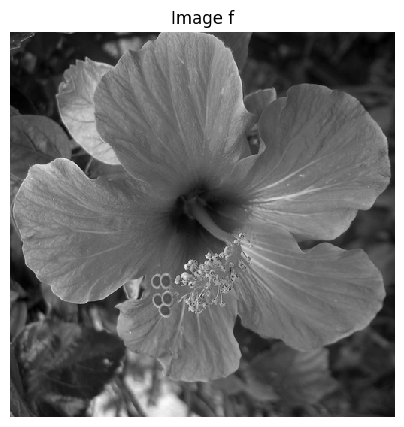

In [3]:
plt.figure(figsize = (5,5))
imageplot(f, 'Image f')

Display a zoom in the middle.

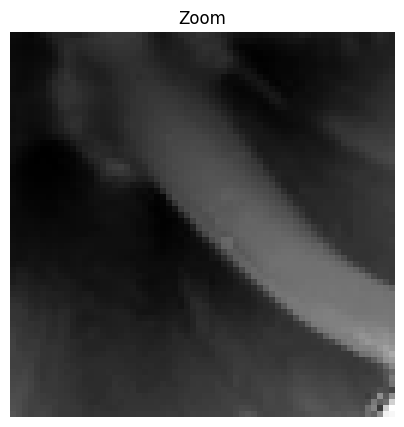

In [4]:
plt.figure(figsize = (5,5))
imageplot(f[n0//2 - 32:n0//2 + 32,n0//2 - 32:n0//2 + 32], 'Zoom')

An image is a 2D array, it can be modified as a matrix.

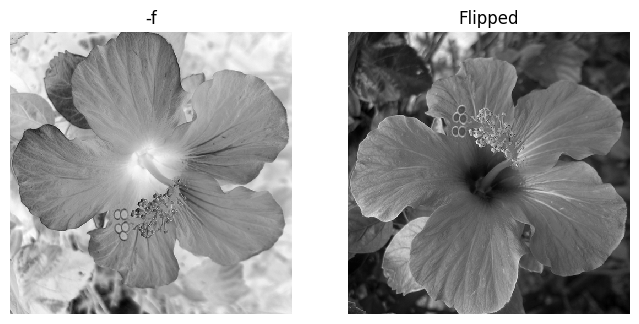

In [5]:
plt.figure(figsize = (8,8))
imageplot(-f, '-f', [1, 2, 1])
imageplot(f[::-1,], 'Flipped', [1, 2, 2])

Blurring is achieved by computing a convolution $f \star h$ with a kernel $h$.


Compute the low pass kernel.

In [6]:
k = 9; #size of the kernel
h = np.ones([k,k])
h = h/np.sum(h) #normalize

Compute the convolution $f \star h$.

In [7]:
from scipy import signal
fh = signal.convolve2d(f, h, boundary = "symm")

Display.

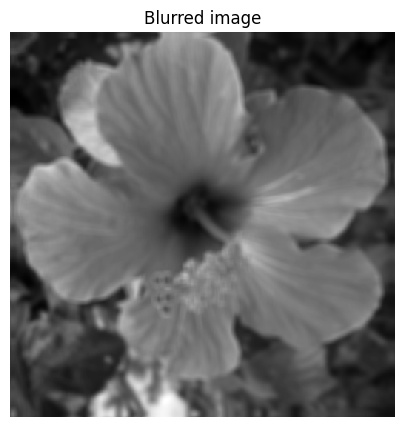

In [8]:
plt.figure(figsize = (5,5))
imageplot(fh, 'Blurred image')

Fourier Transform
-----------------
The Fourier orthonormal basis is defined as
$$ \psi_m(k) = \frac{1}{\sqrt{N}}e^{\frac{2i\pi}{N_0} \dotp{m}{k} } $$
where $0 \leq k_1,k_2 < N_0$ are position indexes,
and $0 \leq m_1,m_2 < N_0$ are frequency indexes.


The Fourier transform $\hat f$ is the projection of the image on this Fourier
basis

$$ \hat f(m) = \dotp{f}{\psi_m}. $$


The Fourier transform is computed in $ O(N \log(N)) $ operation using the FFT algorithm
(Fast Fourier Transform).
Note the normalization by $\sqrt{N}=N_0$ to make the transform orthonormal.

In [9]:
F = pyl.fft2(f)/n0

We check this conservation of the energy.

In [10]:
from pylab import linalg

print("Energy of Image:   %f" %linalg.norm(f))
print("Energy of Fourier: %f" %linalg.norm(F))

Energy of Image:   205.747421
Energy of Fourier: 205.747421


Compute the logarithm of the Fourier magnitude $ \log\left(\abs{\hat f(m)} +
\epsilon\right) $, for some small $\epsilon$.

In [11]:
L = pyl.fftshift(np.log(abs(F) + 1e-1))

Display. Note that we use the function fftshift to put the 0 low frequency in the
middle.

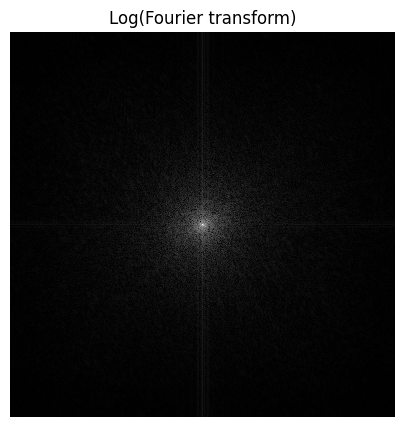

In [12]:
plt.figure(figsize = (5,5))
imageplot(L, 'Log(Fourier transform)')

Linear Fourier Approximation
----------------------------
An approximation is obtained by retaining a certain set of index $I_M$

$$ f_M = \sum_{ m \in I_M } \dotp{f}{\psi_m} \psi_m. $$


Linear approximation is obtained by retaining a *fixed* set $I_M$
of $M = \abs{I_M}$ coefficients. The important point is that $I_M$
does not depend on the image $f$ to be approximated.


For the Fourier transform, a low pass linear approximation
is obtained by keeping only the frequencies within a square.

$$ I_M = \enscond{m=(m_1,m_2)}{ -q/2 \leq m_1,m_2 < q/2 } $$
where $ q = \sqrt{M} $.


This can be achieved by computing the Fourier transform,
setting to zero the $N-M$ coefficients outside the square $I_M$
and then inverting the Fourier transform.


Number $M$ of kept coefficients.

In [13]:
M = n0**2//64
# M = 128

__Exercise 1__

Perform the linear Fourier approximation with $M$ coefficients.
Store the result in the variable $f_M$.

---

In [14]:
def square_mask(matrix, center, size):
    m0 = np.zeros_like(matrix)
    beg = center-size//2
    end = center+size//2

    m0[beg:end,beg:end]=matrix[beg:end,beg:end]
    return m0

pyl.ffshift -> reorganise les frequence de basse-haute-negative en negative-0-positive

ex. Lp = pyl.fftshift(abs(Fp))

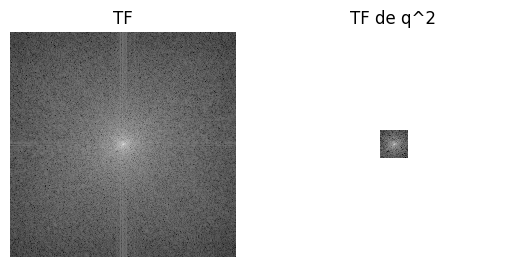

In [15]:
## Insert your code here.

# pyl.fft2 -> fast fourier transform en 2d
# f -> l'image
# n0 -> le nombre de pixel de coté de l'image
F = pyl.fft2(f)/n0

q = int(np.sqrt(M))

Fs = pyl.fftshift(F)
Fms = square_mask(Fs, n0//2, q)

imageplot(np.log(abs(Fs)), 'TF', [1, 2, 1])
imageplot(np.log(abs(Fms)), 'TF de q^2', [1, 2, 2])


In [16]:
Fm = pyl.ifftshift(Fms)
fm = np.real(pyl.ifft2(Fm) * n0)

In [17]:
def fourier_lineaire_2d(x, n):
    f = np.fft.fft2(x, norm="ortho")
    fs = np.fft.fftshift(f)

    q = int(np.sqrt(n))
    center = x.shape[0] // 2

    fms = square_mask(fs, center, q)

    fm = np.fft.ifftshift(fms)

    return np.real(np.fft.ifft2(fm, norm="ortho"))

fm2 = fourier_lineaire_2d(f,M)

Compare two 1D profile (lines of the image).
This shows the strong ringing artifact of the linea approximation.

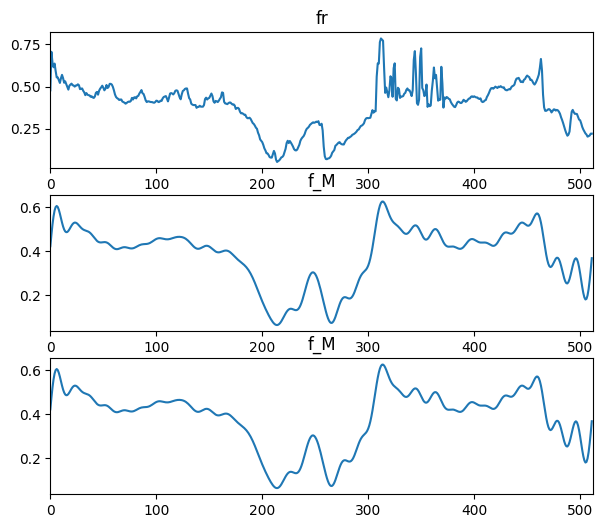

In [18]:
plt.figure(figsize=(7,6))

plt.subplot(3, 1, 1)
plt.plot(f[: , n0//2])
plt.xlim(0,n0)
plt.title('fr')

plt.subplot(3, 1, 2)
plt.plot(fm[: , n0//2])
plt.xlim(0,n0)
plt.title('f_M')

plt.subplot(3, 1, 3)
plt.plot(fm2[: , n0//2])
plt.xlim(0,n0)
plt.title('f_M')

plt.show()

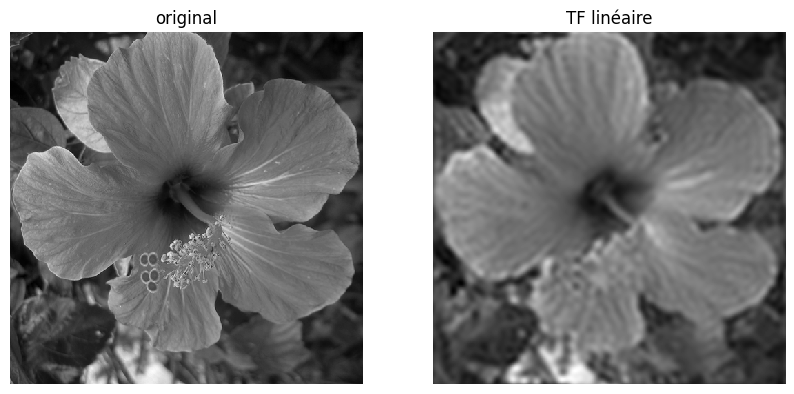

In [19]:
plt.figure(figsize = (10,10))
imageplot(f, 'original', [1, 2, 1])
imageplot(fm, 'TF linéaire', [1, 2, 2])

---

Non-linear Fourier Approximation
--------------------------------
Non-linear approximation is obtained by keeping the $M$ largest
coefficients. This is equivalently computed using a thresholding of the
coefficients
$$ I_M = \enscond{m}{ \abs{\dotp{f}{\psi_m}}>T }. $$


Set a threshold $T>0$.

In [20]:
T = .2

Compute the Fourier transform.

In [21]:
F = pyl.fft2(f)/n0

Do the hard thresholding.

In [22]:
FT = np.multiply(F,(abs(F) > T))

Display. Note that we use the function fftshift to put the 0 low frequency in the
middle.

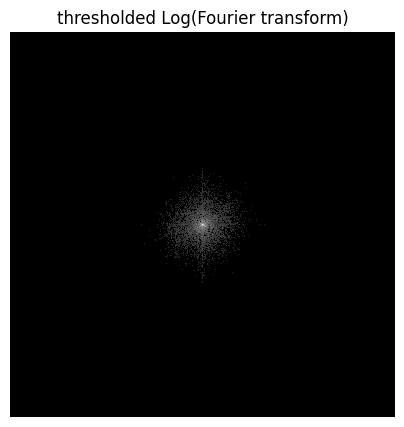

In [23]:
L = pyl.fftshift(np.log(abs(FT) + 1e-1))
plt.figure(figsize = (5,5))
imageplot(L, 'thresholded Log(Fourier transform)')

Inverse Fourier transform to obtain $f_M$.

In [24]:
fM = np.real(pyl.ifft2(FT)*n0)

Display.

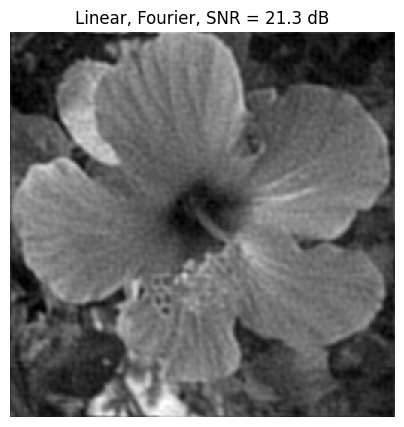

In [25]:
plt.figure(figsize = (5,5))
imageplot(clamp(fM), "Linear, Fourier, SNR = %.1f dB" %snr(f, fM))

Given a $T$, the number of coefficients is obtained by counting the
non-thresholded coefficients $ \abs{I_M} $.

In [26]:
m = np.sum(FT != 0)
print('M/N = 1/%d'  %(n0**2/m))

M/N = 1/53


__Exercise 2__

Compute the value of the threshold $T$ so that the number of
coefficients is $M$. Display the corresponding approximation
$f_M$.

---

In [27]:
F_coef = abs(F)

**/!\ Ce code ne fonctionne pas /!\\**

Il est gardé ici pour etre étudié et comprendre d'ou vient l'erreur

In [28]:
# # je calcule la meme transformation en me souvenant de indices
# idx_col = np.argsort(F_coef, axis=0)
# tmp = np.take_along_axis(F_coef, idx_col, axis=0)
# idx_row = np.argsort(tmp, axis=1)
# F_coef_trie = np.take_along_axis(tmp, idx_row, axis=1)


# # j'applique la transformation sur Fp
# F_trie = np.take_along_axis(
#     np.take_along_axis(F, idx_col, axis=0),
#     idx_row,
#     axis=1
# )
# # il faut faire la rotation ici pour pas tout casser
# F_trie = F_trie[::-1,::-1]

# # je garde les q^2 plus grand coefficients
# F_mask = square_mask(F_trie, q//2, q)

# # inversion du trie
# inv_idx_col = np.argsort(idx_col, axis=0)
# inv_idx_row = np.argsort(idx_row, axis=1)

# F_mask_original = np.take_along_axis(
#     np.take_along_axis(F, inv_idx_col, axis=0),
#     inv_idx_row,
#     axis=1
# )


# plt.figure(figsize = (10,10))
# imageplot(np.log(abs(F)), 'tf', [1, 5, 1])
# imageplot(np.log(abs(tmp)), 'colonne', [1, 5, 2])
# imageplot(np.log(abs(F_trie)), 'trie', [1, 5, 3])
# imageplot(np.log(abs(F_mask)), 'reduit', [1, 5, 4])
# imageplot(np.log(abs(F_mask_original)), 'reduit dé trié', [1, 5, 5])


Version fonctionnelle et rapide

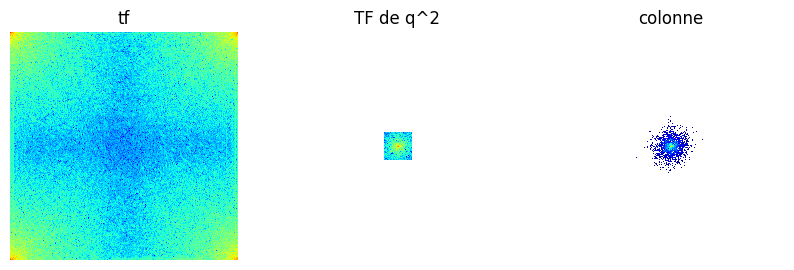

In [29]:
F_flat = F.flatten()                # vrai valeur mise en vecteur
F_coef_flat = F_coef.flatten()      # abs(F) mis en vecteur

# indices triés globalement
idx = np.argsort(F_coef_flat)       # tableau d'indice des coefs triés

# garder les M plus grands
mask = np.zeros_like(F_flat)        
mask[idx[-M:]] = F_flat[idx[-M:]]

# reshape
F_mask = mask.reshape(F.shape)      # on appplique le mask sur F


F_mask_shift = pyl.fftshift(F_mask) # pour rendre le plot plus lisible
plt.figure(figsize = (10,10))
imageplot(np.log(abs(F)), 'tf', [1, 3, 1], 'jet')
imageplot(np.log(abs(Fms)), 'TF de q^2', [1, 3, 2], 'jet')
imageplot(np.log(abs(F_mask_shift)), 'colonne', [1, 3, 3], 'jet')

In [30]:
fmT = np.real(pyl.ifft2(F_mask) * n0)

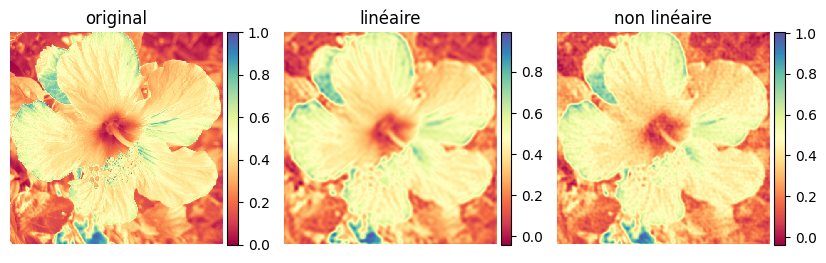

In [49]:
plt.figure(figsize = (10,10))
imageplot(f, 'original', [1, 3, 1], colorbar=True, cmap="Spectral")
imageplot(fm*(np.linalg.norm(f)/np.linalg.norm(fm))
          , 'linéaire', [1, 3, 2], colorbar=True, cmap="Spectral"
          )
imageplot(fmT, 'non linéaire', [1, 3, 3], colorbar=True, cmap="Spectral")

In [47]:
print(np.linalg.norm(f), np.linalg.norm(fm))

205.7474212275565 204.6535156326405


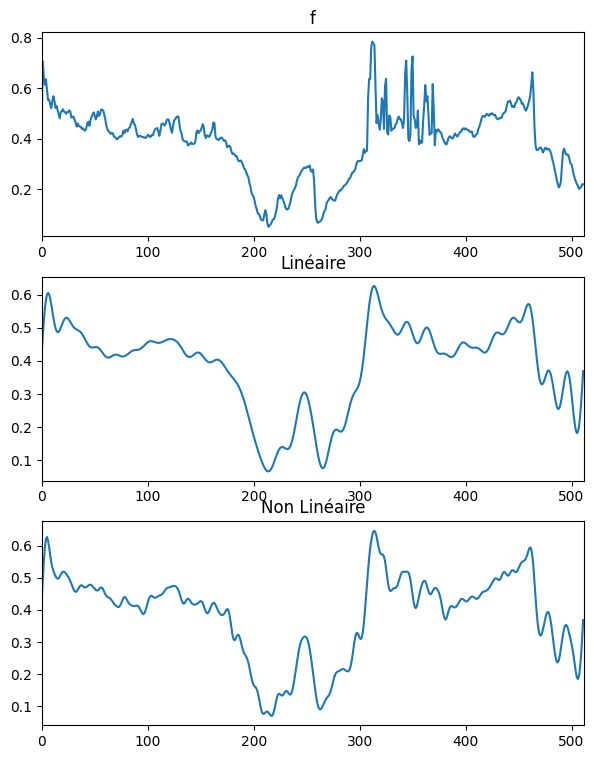

In [32]:
plt.figure(figsize=(7,9))

plt.subplot(3, 1, 1)
plt.plot(f[: , n0//2])
plt.xlim(0,n0)
plt.title('f')

plt.subplot(3, 1, 2)
plt.plot(fm[: , n0//2])
plt.xlim(0,n0)
plt.title('Linéaire')

plt.subplot(3, 1, 3)
plt.plot(fmT[: , n0//2])
plt.xlim(0,n0)
plt.title('Non Linéaire')

plt.show()

---

Wavelet Transform
-----------------
A wavelet basis $\Bb = \{ \psi_m \}_m$
is obtained over the continuous domain by translating and
dilating three mother wavelet functions $ \{\psi^V,\psi^H,\psi^D\} $.


Each wavelet atom is defined as
$$ \psi_m(x) = \psi_{j,n}^k(x) = \frac{1}{2^j}\psi^k\pa{ \frac{x-2^j n}{2^j} } $$

The scale (size of the support) is $2^j$ and the position is
$2^j(n_1,n_2)$. The index is $ m=(k,j,n) $ for $\{ j \leq 0 \}$.


The wavelet transform computes all the inner products
$ \{ \dotp{f}{\psi_{j,n}^k} \}_{k,j,n} $.


Set the minimum scale for the transform to be 0.

In [33]:
Jmin = 8 # échelle minimal conservée

Perform the wavelet transform,  $f_w$ stores all the wavelet coefficients.

(512, 512)


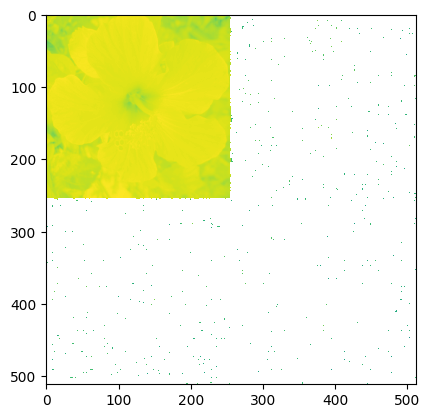

In [34]:
from nt_toolbox.perform_wavelet_transf import *

fw = perform_wavelet_transf(f, Jmin, + 1)

print(fw.shape)

plt.imshow(np.log(fw))
plt.show()

Display the transformed coefficients.

**Cf. cascade des coefficient du livre de Mallat partie 5.5.1**

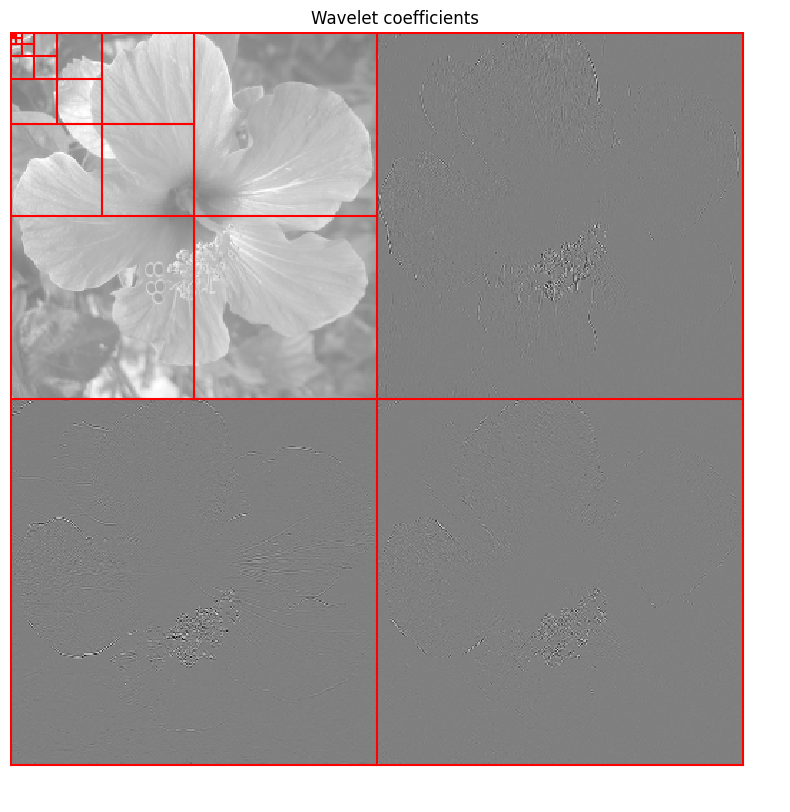

In [35]:
plt.figure(figsize=(10,10))

plot_wavelet(fw)
plt.title('Wavelet coefficients')

plt.show()

---

J'aimerais refaire la meme vizualisation avec pywavelet

Basé sur la page [Overview of multilevel wavelet decompositions](https://pywavelets.readthedocs.io/en/latest/ref/2d-decompositions-overview.html) de la doc de pywavelet.
![doc](ressources/wavelet_doc.png)

In [36]:
import pywt

wavelet = 'bior4.4'                             # type de wavelet équivalent a 9-7

level = pywt.dwtn_max_level(f.shape, wavelet)   # calcule le nombre maximum de niveau de decomposition (combien de fois je peux diviser par 2)
                                                # ce qui equivaut a Jmax-Jmin = (log2(n)-1)-Jmin

## Transformé en ondelettes ##
# Résutlat sous forme :
# coeffs = [
#    cA,              # basse fréquence (approximation)
#    (cH1, cV1, cD1), # détails niveau 1
#    (cH2, cV2, cD2),
#    ...
#    ]
coeffs = pywt.wavedec2(f, wavelet=wavelet, level=level) 





arr, slices = pywt.coeffs_to_array(coeffs)      # Transforme la structure en image 2D unique
                                                # arr → image des coefficients (comme ton fw)
                                                # slices → indices pour retrouver chaque bloc

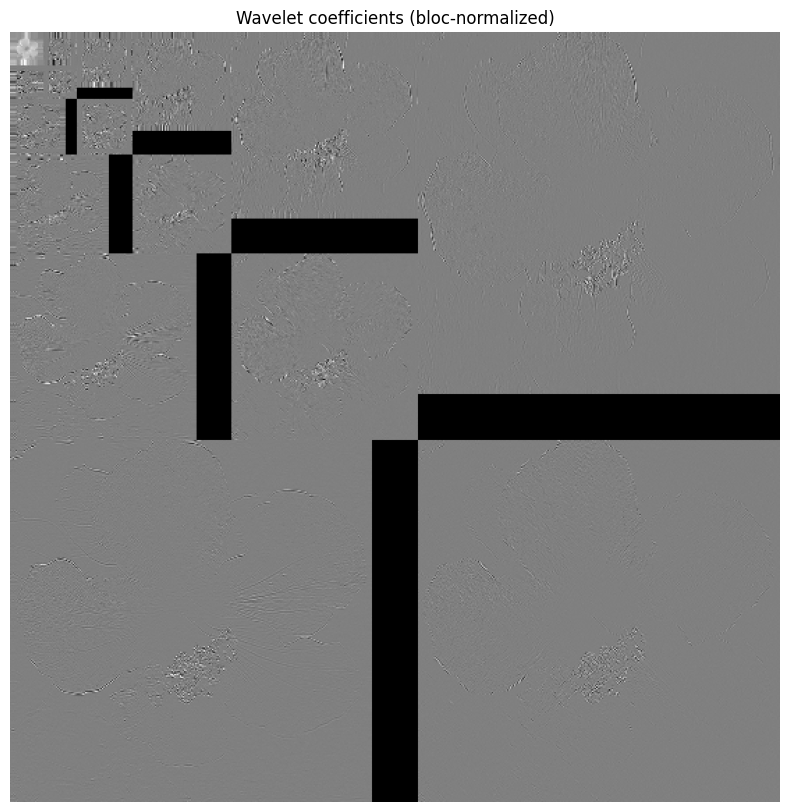

In [37]:
# Fonction qui pemert de renormalisé chaque bande independament 
# fait pas GPT pour un but de verification visuelle par rapport a celle au dessus
def normalize_per_block(arr, slices):
    arr_norm = arr.copy()

    # --- Approximation (basse fréquence)
    approx_slice = slices[0]
    block = arr_norm[approx_slice]
    vmax = np.max(np.abs(block))
    if vmax > 0:
        arr_norm[approx_slice] = 0.5 + 0.5 * block / vmax

    # --- Détails (chaque niveau)
    for level in slices[1:]:
        for key in ['ad', 'da', 'dd']:  # horiz, vert, diag
            sl = level[key]
            block = arr_norm[sl]
            vmax = np.max(np.abs(block))
            if vmax > 0:
                arr_norm[sl] = 0.5 + 0.5 * block / vmax

    return arr_norm

arr_norm = normalize_per_block(arr, slices)

plt.figure(figsize=(10,10))
plt.imshow(arr_norm, cmap='gray')
plt.title("Wavelet coefficients (bloc-normalized)")
plt.axis('off')
plt.show()

Les grosses bande noires ici viennent du fait que le calcule des wavelet par pywavelet utilise un padding symetric au bord pour gerer les filtres long ( ici brio4.4 -> 9/5 ) donc il arrive que la decomposition creer un phenomeme type, 

256x256->128x128->65x65 puis l'erreur se propage creant des bandes de 0 non codant 

Ce phénomeme mise a part l'image est bien similaire a celle souhaité !

---

Wavelet Approximation
---------------------
Linear wavelet approximation with $M=2^{-j_0}$ coefficients is obtained
by keeping only the coarse scale (large support) wavelets:

$$I_M = \enscond{(k,j,n)}{ j \geq j_0 }.$$


It corresponds to setting to zero all the coefficients excepted those
that are on the upper left corner of $f_w$.

__Exercise 3__

Perform linear approximation with $M$ wavelet coefficients.

---

**Remarque :**

<span style="color:red">
Dans wavedec2; level n'est PAS le nombre de coefficients mais le nombre de niveau de decomposition
</span> 
(J'ai été tenté de penser ca plusieurs fois)

Ici on voit qu'appliquer la meme idée que pour Fourier pour garder les M plus grand coefficients ne fonctionne pas a cause de la structure multi échelle des winglets, la reconstruction se fait mal

In [38]:
# Rappel M = n0**2//64

coeffs = pywt.wavedec2(f, wavelet) # calculer automatiquement avec level = level_max
# Foramt de la sortie,
# coeffs = [
#     cA,                  ← coeffs[0]
#     (cH1, cV1, cD1),
#     (cH2, cV2, cD2),
#     ...
# ]

**Code d'exemple de git:** permet de conserver tous les coefficients > T ( ce qui ne garantie pas d'avoir un nombre precis de coefficients M conservé ) 
```python
coeffs = pywt.wavedec2(f, wavelet)

coeffs_thresh = []
coeffs_thresh.append(coeffs[0])  # approximation conservée

for detail in coeffs[1:]:
    coeffs_thresh.append(tuple(
        pywt.threshold(subband, T, mode='hard')
        for subband in detail
    ))

fr = pywt.waverec2(coeffs_thresh, wavelet)
```


In [39]:
arr, slices = pywt.coeffs_to_array(coeffs)
flat = np.abs(arr).flatten()

# Tr = np.sort(flat)[-M]
Tr = np.partition(flat, -M)[-M]           # Sépare le tableau en 2 partie les élements
                                            # [ . . . . | T | gros | très gros | énorme ] 
                                            # mais ca ne trie pas completement, scale en O(n) contrairement a un sort O(n log(n))

coeffs_thresh = []
coeffs_thresh.append(coeffs[0])             # On conserve cA qui correspond au basses fréquences


for detail in coeffs[1:]:
    cH, cV, cD = detail

    cH_thresh = cH * (np.abs(cH) >= Tr)
    cV_thresh = cV * (np.abs(cV) >= Tr)
    cD_thresh = cD * (np.abs(cD) >= Tr)

    coeffs_thresh.append((cH_thresh, cV_thresh, cD_thresh))

fr = pywt.waverec2(coeffs_thresh, wavelet)


**Remarque:**
Ou pourrais ecrire la boucle de facon compacte 
```python
for detail in coeffs[1:]: 
    coeffs_thresh.append(tuple(             
        subband * (np.abs(subband) >= Tr)  
        for subband in detail               
    ))
```


In [40]:
arr_mask_norm = normalize_per_block(arr_mask, slices)

plt.figure(figsize=(10,10))
plt.imshow(arr_mask_norm, cmap='gray')
plt.title("Wavelet tresholded coefficients (bloc-normalized)")
plt.axis('off')
plt.show()

NameError: name 'arr_mask' is not defined

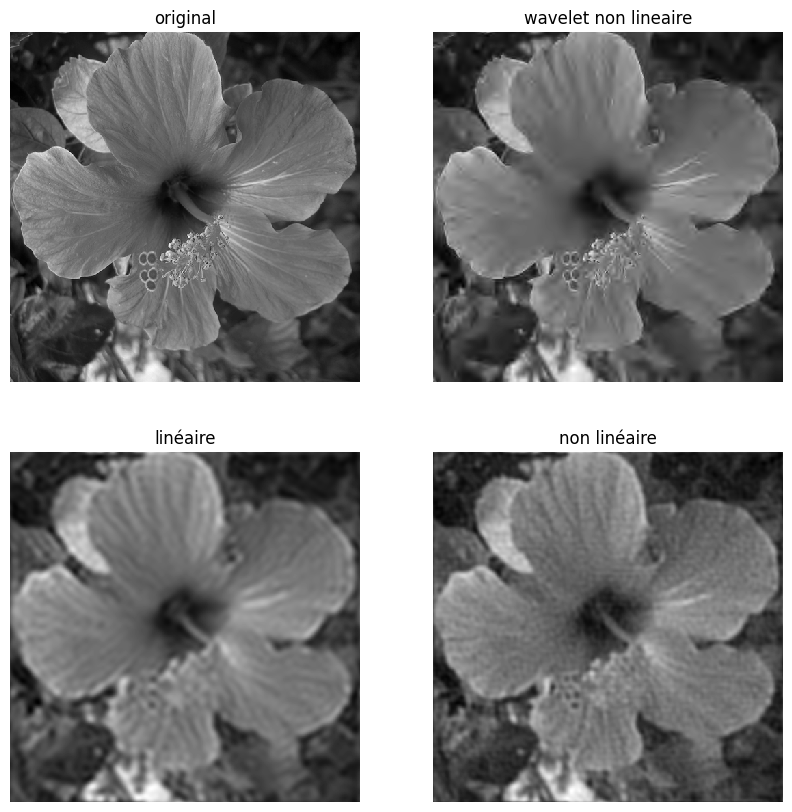

In [ ]:
plt.figure(figsize = (10,10))
imageplot(f,    'original',              [2, 2, 1])
imageplot(fr,   'wavelet non lineaire',  [2, 2, 2])
imageplot(fm,   'linéaire',              [2, 2, 3])
imageplot(fmT,  'non linéaire',          [2, 2, 4])

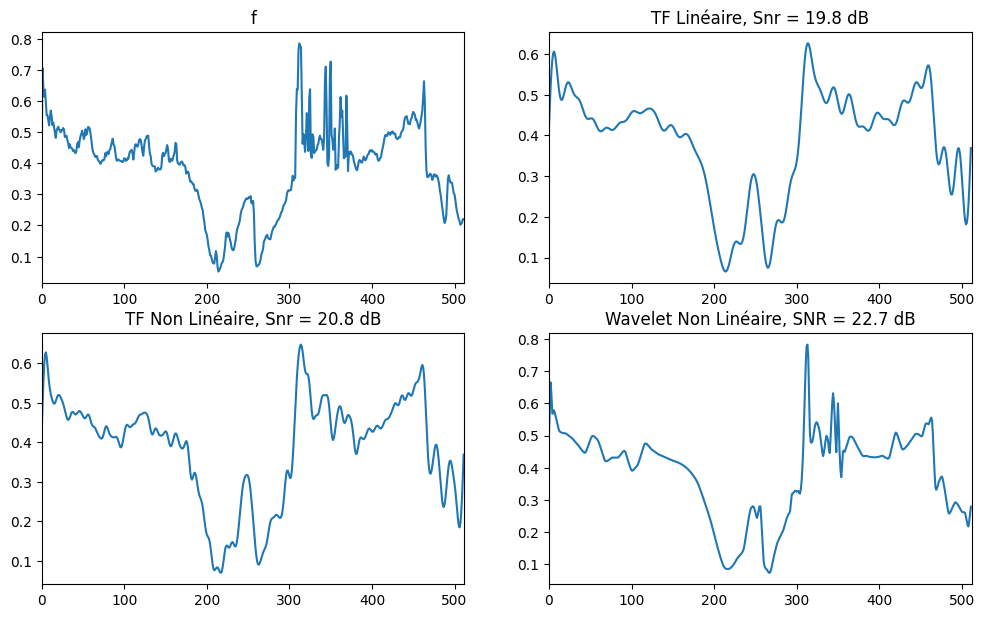

In [ ]:
plt.figure(figsize=(12,15))

plt.subplot(4, 2, 1)
plt.plot(f[: , n0//2])
plt.xlim(0,n0)
plt.title('f')

plt.subplot(4, 2, 2)
plt.plot(fm[: , n0//2])
plt.xlim(0,n0)
plt.title("TF Linéaire, Snr = %.1f dB" %snr(f, fm))

plt.subplot(4, 2, 3)
plt.plot(fmT[: , n0//2])
plt.xlim(0,n0)
plt.title("TF Non Linéaire, Snr = %.1f dB" %snr(f, fmT))

plt.subplot(4, 2, 4)
plt.plot(fr[: , n0//2])
plt.xlim(0,n0)
plt.title("Wavelet Non Linéaire, SNR = %.1f dB" %snr(f, fr))

plt.show()

---